#  SVD Movie Recommendation

### 1. Import Libraries

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

### 2. Read u.data and u.item

In [3]:
ratings = pd.read_csv(
    "../data/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
movies = pd.read_csv(
    "../data/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["movie_id", "movie_title"]
)

movies.head()

,movie_id,movie_title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


### 3. Create the User × Movie Matrix

In [5]:
rating_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

rating_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4. Deal with missing ratings

In [6]:
rating_matrix = rating_matrix.fillna(0)

rating_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 5. Apply SVD

In [7]:
A = rating_matrix.values

U, S, VT = np.linalg.svd(A, full_matrices=False)

### 6. Look at the Singular Values

In [8]:
print(S[:20])

[640.63362257 244.83634567 217.84622472 159.15359872 158.21191449
 145.87261327 126.57977314 121.90769976 106.8291837   99.74793974
  93.79885965  93.25844284  89.91150168  84.34178722  83.81220836
  81.81204105  79.07796788  77.88652669  76.387996    75.3415951 ]


### 7. Graph Singular Values vs. r

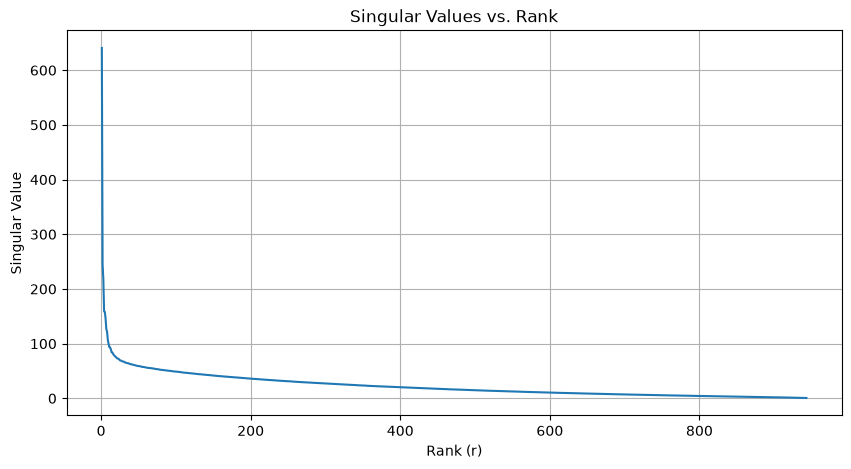

In [9]:
r = np.arange(1, len(S) + 1)

plt.figure(figsize=(10, 5))
plt.plot(r, S)
plt.xlabel("Rank (r)")
plt.ylabel("Singular Value")
plt.title("Singular Values vs. Rank")
plt.grid(True)
plt.show()

### 8. Calculate cumulative information

In [10]:
cumulative_sum = np.cumsum(S**2) / np.sum(S**2)

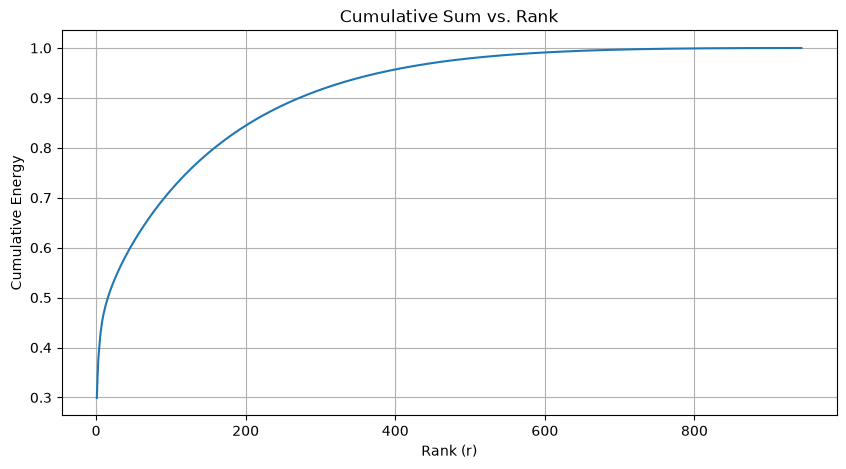

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(r, cumulative_sum)
plt.xlabel("Rank (r)")
plt.ylabel("Cumulative Energy")
plt.title("Cumulative Sum vs. Rank")
plt.grid(True)
plt.show()

### 9. Choose r

In [12]:
for percentage in [0.80, 0.90, 0.95, 0.99]:
    r_selected = np.argmax(cumulative_sum >= percentage) + 1
    print(f"{percentage*100:.0f}% information: r = {r_selected}")

80% information: r = 159
90% information: r = 272
95% information: r = 378
99% information: r = 588


### 10. Reconstruct the rating matrix

In [13]:
r = 50

In [14]:
A_approx = U[:, :r] @ np.diag(S[:r]) @ VT[:r, :]

### 11. Make movie recommendations

In [15]:
user_id = 1

user_index = rating_matrix.index.get_loc(user_id)

predicted_ratings = A_approx[user_index]

already_rated = rating_matrix.iloc[user_index].values > 0

predicted_ratings[already_rated] = -1

top_movies = np.argsort(predicted_ratings)[-10:][::-1]

recommended_movie_ids = rating_matrix.columns[top_movies]

recommendations = movies[
    movies["movie_id"].isin(recommended_movie_ids)
]

recommendations

,movie_id,movie_title
302,303,Ulee's Gold (1997)
356,357,One Flew Over the Cuckoo's Nest (1975)
366,367,Clueless (1995)
384,385,True Lies (1994)
402,403,Batman (1989)
422,423,E.T. the Extra-Terrestrial (1982)
469,470,Tombstone (1993)
549,550,Die Hard: With a Vengeance (1995)
581,582,"Piano, The (1993)"
731,732,Dave (1993)
